In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
titanic=sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [5]:
#Handle missing values
from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
#encoding

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [10]:
X=titanic[features]
y=titanic[target]

In [11]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [12]:
#decsion tree model -> no pruning

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()

model.fit(X_train,y_train)

DecisionTreeClassifier()

In [14]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)

print("accuracy is",accuracy_score(y_test,y_pred))

accuracy is 0.7653631284916201


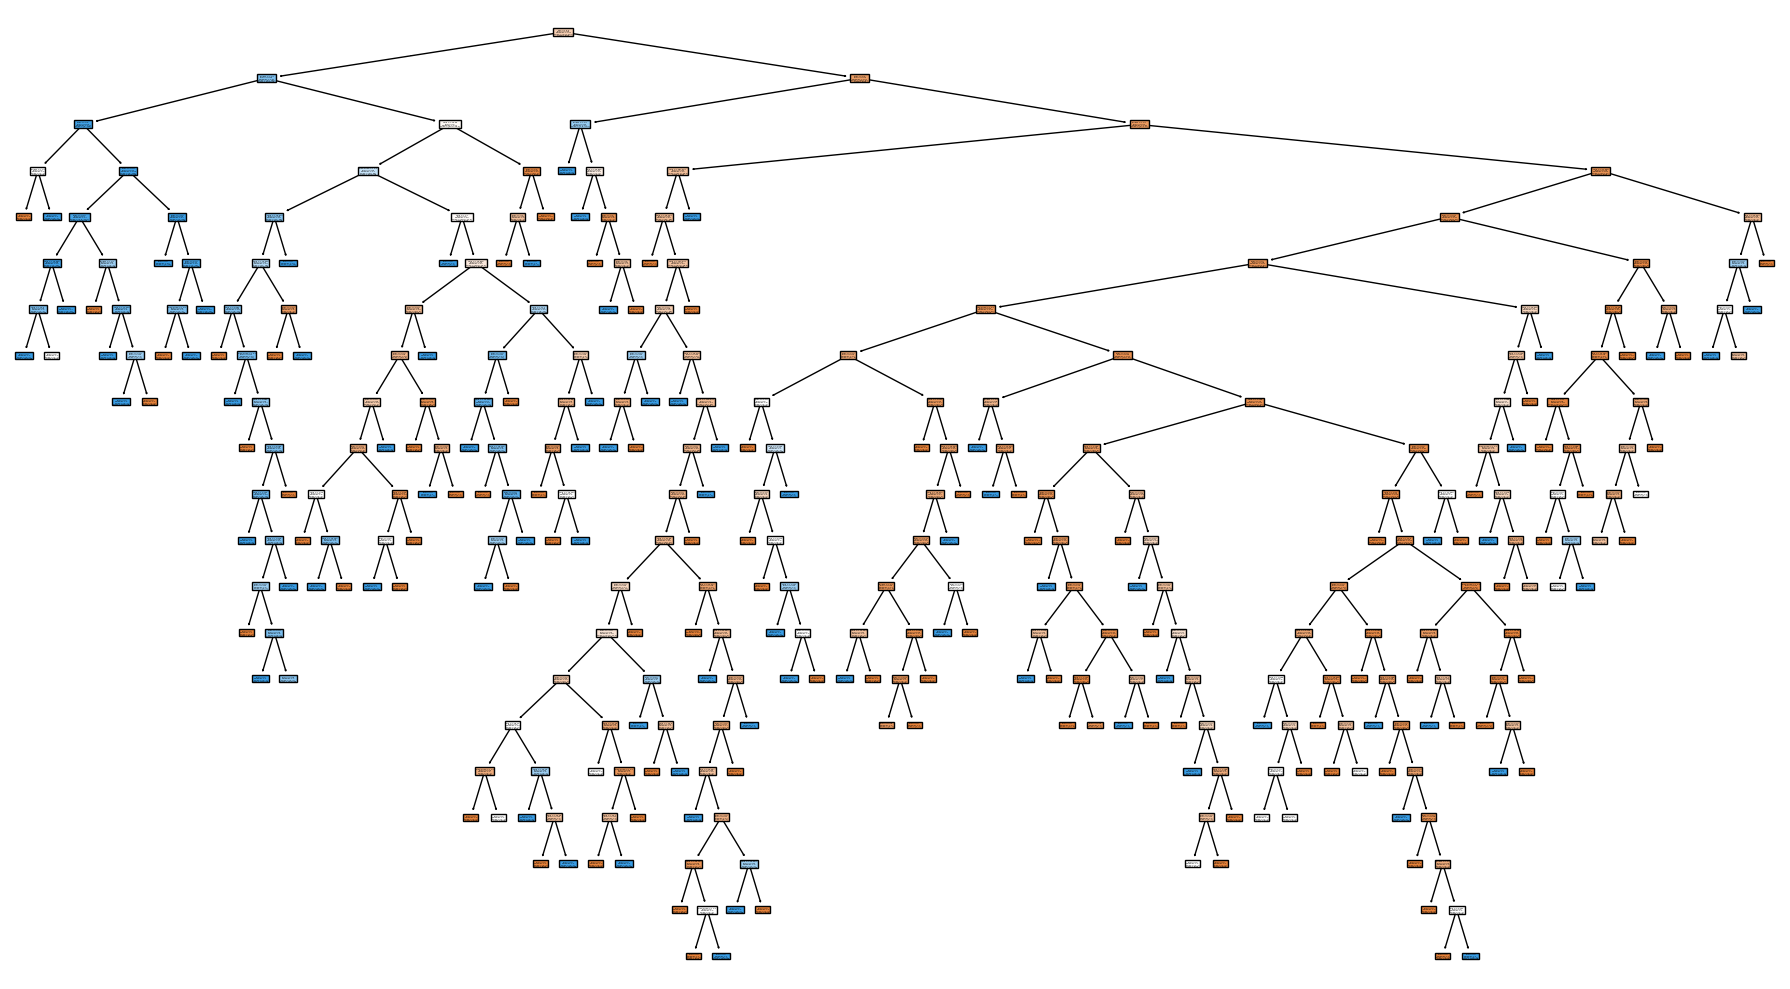

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True
)

plt.tight_layout()
plt.show()

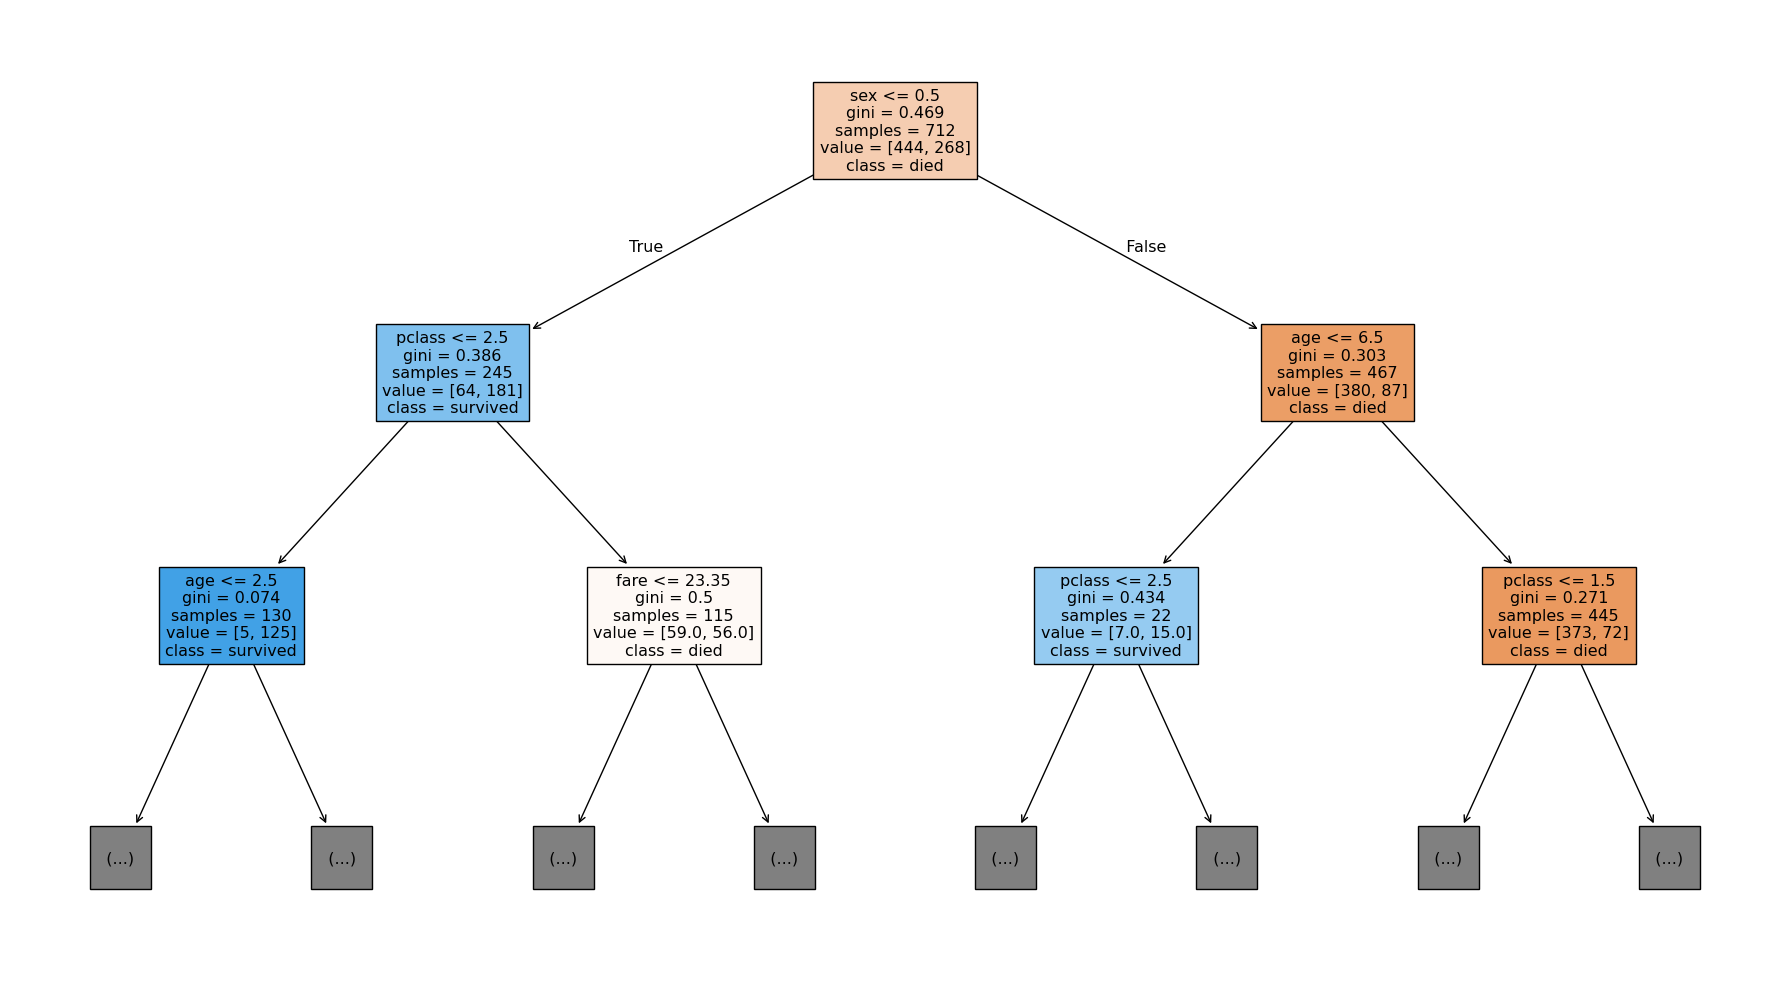

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

for depth=2 accuracy=0.7653631284916201
for depth=3 accuracy=0.7988826815642458
for depth=4 accuracy=0.7988826815642458
for depth=5 accuracy=0.7988826815642458
for depth=6 accuracy=0.8044692737430168


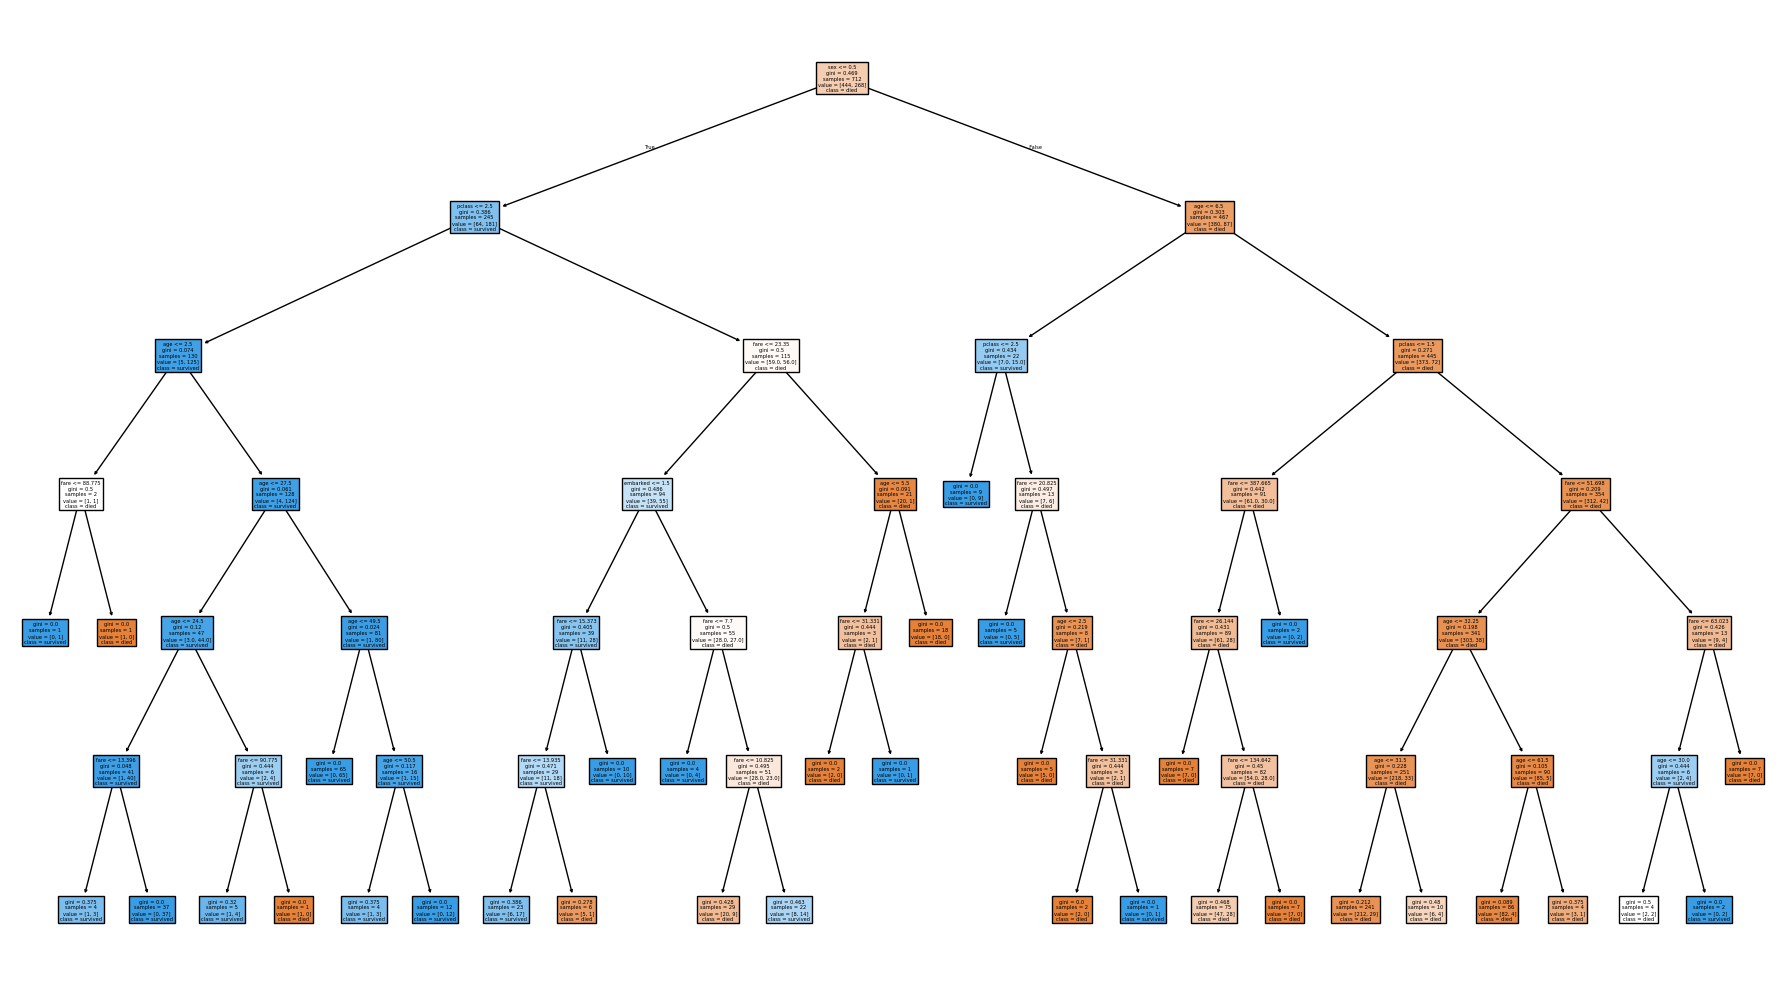

for depth=7 accuracy=0.7932960893854749
for depth=8 accuracy=0.7877094972067039
for depth=90 accuracy=0.770949720670391


In [26]:
#with pruining

depths=[2,3,4,5,6,7,8,90]

for depth in depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    acc= model.score(X_test,y_test)

    print(f"for depth={depth} accuracy={acc}")

    if depth==6:
        plt.figure(figsize=(18,10))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["died","survived"],
            filled=True,
        )
        
        plt.tight_layout()
        plt.show()
        

In [23]:
min_sample_split=[5,10,15,20,25]

for split in min_sample_split:
    model=DecisionTreeClassifier(max_depth=6,min_samples_split=split)
    model.fit(X_train,y_train)
    acc= model.score(X_test,y_test)

    print(f"for split={split} accuracy={acc}")

for split=5 accuracy=0.8044692737430168
for split=10 accuracy=0.8100558659217877
for split=15 accuracy=0.8044692737430168
for split=20 accuracy=0.8044692737430168
for split=25 accuracy=0.7988826815642458


In [32]:
#post pruning

full_tree=DecisionTreeClassifier()
full_tree.fit(X_train,y_train)

DecisionTreeClassifier()

In [34]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)

ccp_alphas=path.ccp_alphas
print(ccp_alphas)


[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 2.34082397e-04 3.51123596e-04 4.68164794e-04 4.68164794e-04
 5.61797753e-04 6.24219725e-04 6.67991230e-04 7.02247191e-04
 7.02247191e-04 8.19288390e-04 8.19288390e-04 8.32292967e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.02996255e-03 1.05337079e-03
 1.07400895e-03 1.08038029e-03 1.11865144e-03 1.12359551e-03
 1.12359551e-03 1.13139825e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.47927070e-03 1.51142557e-03 1.54072312e-03 1.56675436e-03
 1.60434338e-03 1.66892062e-03 1.75561798e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [38]:
#train for all alpha

tree=[]

for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)

    tree.append((model,alpha))

In [39]:
best_acc=0
best_alpha=0

for model,alpha in tree:
    acc=model.score(X_test,y_test)
    if acc>best_acc :
        best_acc=acc
        best_alpha=alpha

In [41]:
best_acc

0.8379888268156425

In [42]:
best_tree=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_tree.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183))

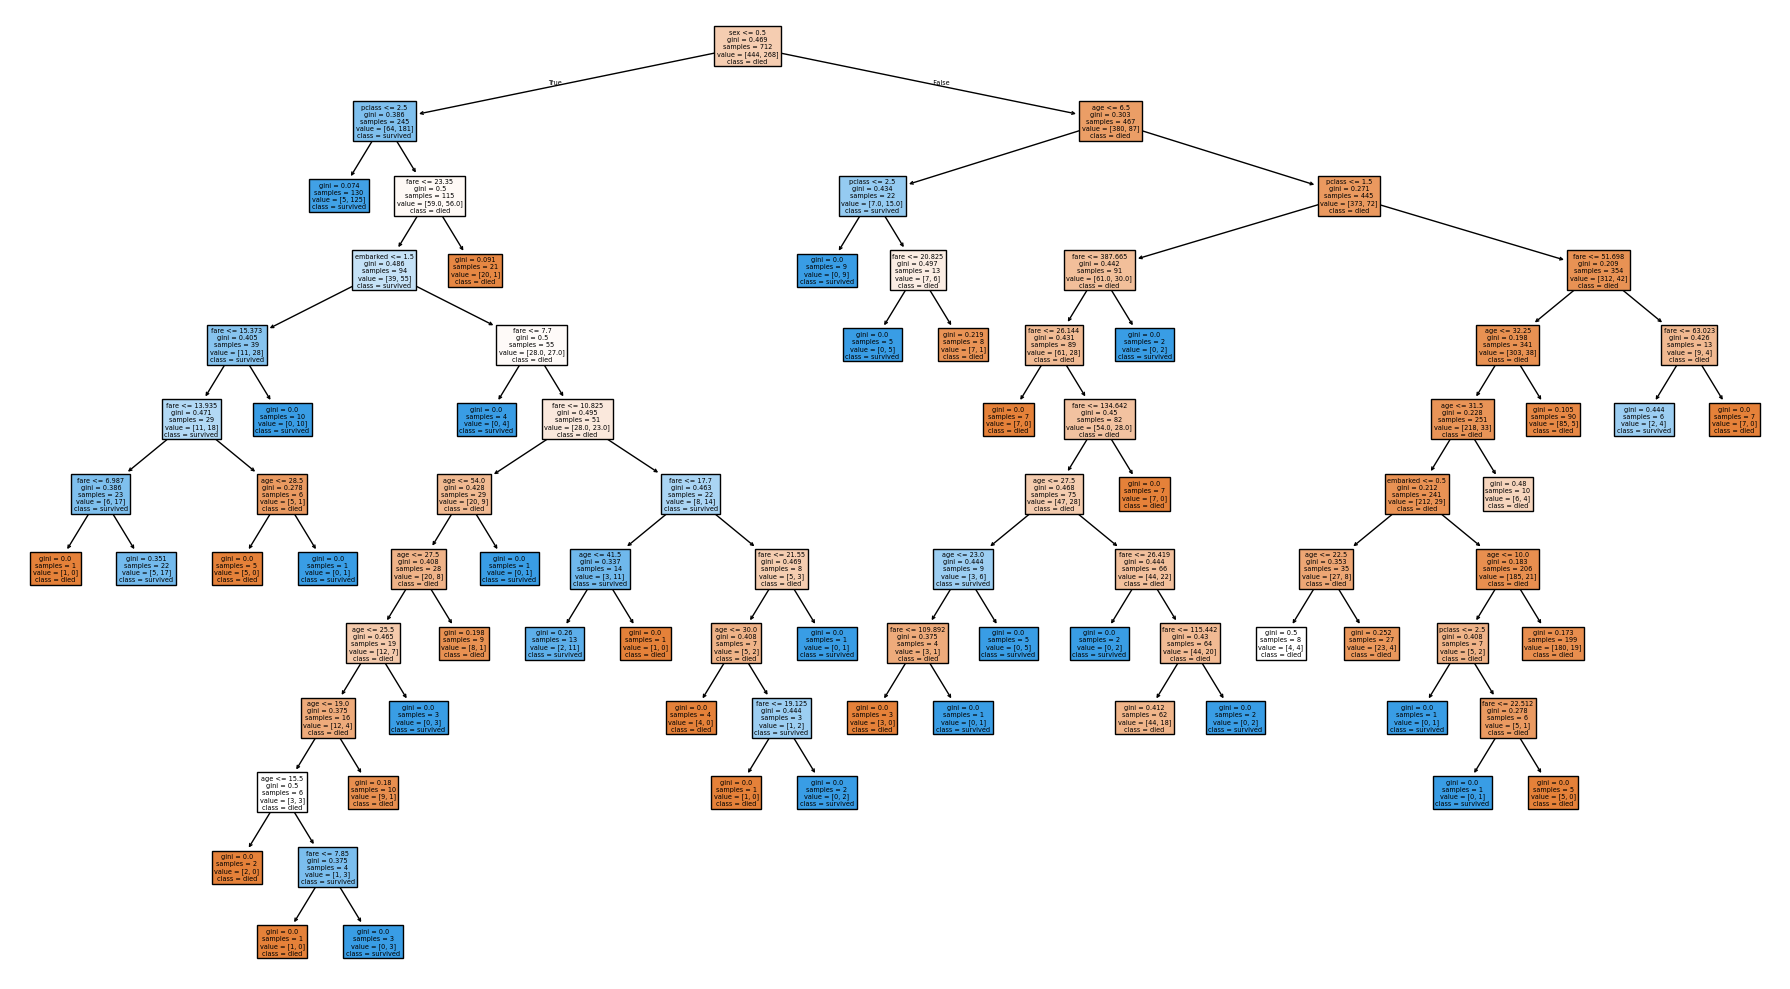

In [44]:
plt.figure(figsize=(18,10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
)
        
plt.tight_layout()
plt.show()

In [45]:
#Decision tree for regression

import matplotlib as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [46]:
df=load_diabetes(as_frame=True).frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [51]:
X=df.drop("target", axis=1)
y=df["target"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [54]:
from sklearn.tree import DecisionTreeRegressor

model=DecisionTreeRegressor()

model.fit(X_train,y_train)

DecisionTreeRegressor()

In [58]:
from sklearn.metrics import r2_score,mean_squared_error

y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

print("mse train",mean_squared_error(y_train,y_pred_train))
print("mse test",mean_squared_error(y_test,y_pred_test))

print("r2 score", r2_score(y_train,y_pred_train))
print("mse test",r2_score(y_test,y_pred_test))

mse train 0.0
mse test 5752.834586466165
r2 score 1.0
mse test -0.06567369631708297
